In [188]:
import pandas as pd
import numpy as np

data = pd.read_csv('aice_binary_churn_review.csv')

data.shape

(628, 15)

In [189]:
data.head()

,customer_id,age,gender,region,plan_type,contract_type,payment_method,signup_date,tenure_months,monthly_fee,support_calls,late_payments,avg_weekly_hours,auto_payment,churn
0,C100133,24.0,Male,Seoul,Basic,Monthly,Virtual account,2025-03-30,9.0,15.3,3.0,0.0,6.7,No,0
1,C100325,47.0,Male,Gwangju,Basic,Monthly,Virtual account,2024-08-29,16.0,26.4,3.0,0.0,2.2,No,1
2,C100027,53.0,Female,Daegu,Premium,One-year,Card,2025-11-04,1.0,79.3,1.0,2.0,6.8,No,0
3,C100079,22.0,Female,Busan,Premium,Two-year,Virtual account,2025-12-15,1.0,70.2,1.0,0.0,3.7,Yes,0
4,C100355,23.0,Female,Daejeon,Basic,Monthly,Card,2023-10-26,26.0,25.7,1.0,1.0,2.0,No,0


In [190]:
data.isnull().sum()

customer_id         0
age                 7
gender              5
region              7
plan_type           4
contract_type       0
payment_method      5
signup_date         4
tenure_months       0
monthly_fee         8
support_calls       6
late_payments       0
avg_weekly_hours    7
auto_payment        0
churn               0
dtype: int64

In [191]:
data.describe()

,age,tenure_months,monthly_fee,support_calls,late_payments,avg_weekly_hours,churn
count,621.000000,628.000000,620.000000,622.000000,628.000000,621.000000,628.000000
mean,39.697262,23.079618,42.069516,1.594855,0.767516,4.644605,0.127389
std,10.885110,14.365474,22.864224,1.585920,0.849108,3.413752,0.333673
min,19.000000,1.000000,3.300000,0.000000,0.000000,0.200000,0.000000
25%,32.000000,10.000000,25.200000,1.000000,0.000000,2.300000,0.000000
50%,40.000000,23.000000,40.700000,1.000000,1.000000,4.000000,0.000000
75%,46.000000,36.000000,50.000000,2.000000,1.000000,6.200000,0.000000
max,112.000000,47.000000,265.000000,21.000000,5.000000,42.000000,1.000000


In [192]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 628 entries, 0 to 627
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       628 non-null    str    
 1   age               621 non-null    float64
 2   gender            623 non-null    str    
 3   region            621 non-null    str    
 4   plan_type         624 non-null    str    
 5   contract_type     628 non-null    str    
 6   payment_method    623 non-null    str    
 7   signup_date       624 non-null    str    
 8   tenure_months     628 non-null    float64
 9   monthly_fee       620 non-null    float64
 10  support_calls     622 non-null    float64
 11  late_payments     628 non-null    float64
 12  avg_weekly_hours  621 non-null    float64
 13  auto_payment      628 non-null    str    
 14  churn             628 non-null    int64  
dtypes: float64(6), int64(1), str(8)
memory usage: 73.7 KB


In [193]:
data.duplicated().sum()

np.int64(8)

In [194]:
print(data['churn'].value_counts())
print(data['churn'].value_counts(normalize=True))

churn
0    548
1     80
Name: count, dtype: int64
churn
0    0.872611
1    0.127389
Name: proportion, dtype: float64


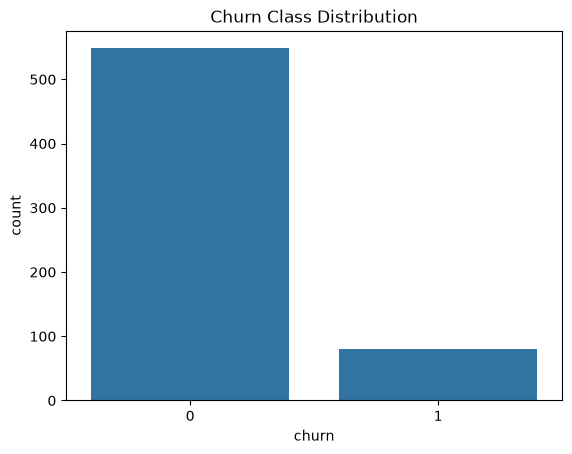

In [195]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(data=data, x='churn')

plt.title('Churn Class Distribution')

plt.show()
# 불균형 데이터라 strarify가 필요하다.

In [196]:
data = data.drop_duplicates().reset_index(drop=True)

In [197]:
data.shape

(620, 15)

In [198]:
data['signup_date'] = pd.to_datetime(data['signup_date'])

data['signup_year'] = data['signup_date'].dt.year
data['signup_month'] = data['signup_date'].dt.month
data['signup_day'] = data['signup_date'].dt.day
data['signup_dayofweek'] = data['signup_date'].dt.dayofweek

def median_fill(col):
    data[col] = data[col].fillna(data[col].median())

def mode_fill(col):
    data[col] = data[col].fillna(data[col].mode()[0])

data['avg_weekly_hours'] = data['avg_weekly_hours'].fillna(data['avg_weekly_hours'].mean())
mode_fill('gender')
mode_fill('region')
mode_fill('plan_type')
mode_fill('payment_method')

median_fill('age')
median_fill('monthly_fee')
median_fill('support_calls')

data = data.dropna(axis=0)
data.reset_index(drop=True, inplace=True)


In [199]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 616 entries, 0 to 615
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   customer_id       616 non-null    str           
 1   age               616 non-null    float64       
 2   gender            616 non-null    str           
 3   region            616 non-null    str           
 4   plan_type         616 non-null    str           
 5   contract_type     616 non-null    str           
 6   payment_method    616 non-null    str           
 7   signup_date       616 non-null    datetime64[us]
 8   tenure_months     616 non-null    float64       
 9   monthly_fee       616 non-null    float64       
 10  support_calls     616 non-null    float64       
 11  late_payments     616 non-null    float64       
 12  avg_weekly_hours  616 non-null    float64       
 13  auto_payment      616 non-null    str           
 14  churn             616 non-null    int

In [200]:
data.isnull().sum()

customer_id         0
age                 0
gender              0
region              0
plan_type           0
contract_type       0
payment_method      0
signup_date         0
tenure_months       0
monthly_fee         0
support_calls       0
late_payments       0
avg_weekly_hours    0
auto_payment        0
churn               0
signup_year         0
signup_month        0
signup_day          0
signup_dayofweek    0
dtype: int64

In [201]:
data.duplicated().sum()

np.int64(0)

In [202]:
data['signup_date'].dtype

dtype('<M8[us]')

In [203]:

data[['signup_year', 'signup_month', 'signup_day', 'signup_dayofweek']].head()

,signup_year,signup_month,signup_day,signup_dayofweek
0,2025.0,3.0,30.0,6.0
1,2024.0,8.0,29.0,3.0
2,2025.0,11.0,4.0,1.0
3,2025.0,12.0,15.0,0.0
4,2023.0,10.0,26.0,3.0


In [204]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 616 entries, 0 to 615
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   customer_id       616 non-null    str           
 1   age               616 non-null    float64       
 2   gender            616 non-null    str           
 3   region            616 non-null    str           
 4   plan_type         616 non-null    str           
 5   contract_type     616 non-null    str           
 6   payment_method    616 non-null    str           
 7   signup_date       616 non-null    datetime64[us]
 8   tenure_months     616 non-null    float64       
 9   monthly_fee       616 non-null    float64       
 10  support_calls     616 non-null    float64       
 11  late_payments     616 non-null    float64       
 12  avg_weekly_hours  616 non-null    float64       
 13  auto_payment      616 non-null    str           
 14  churn             616 non-null    int

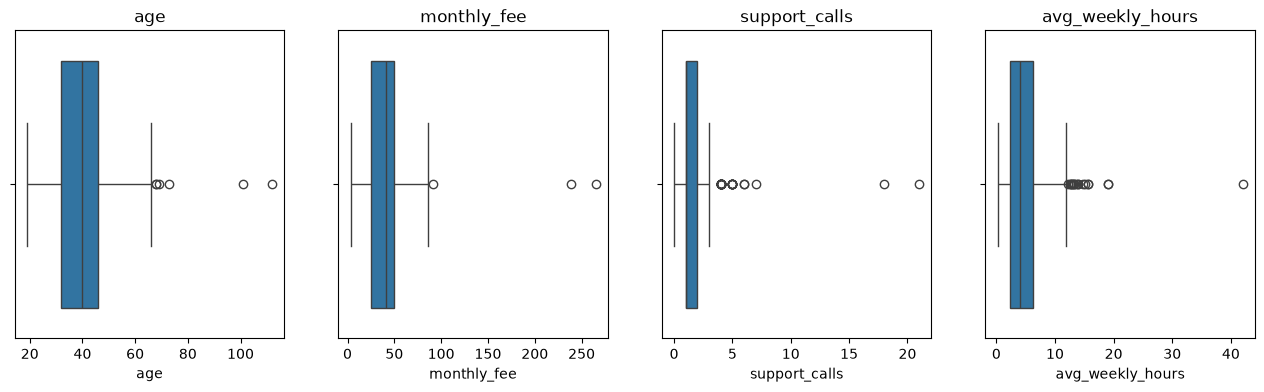

In [205]:
# 수치형 컬럼
outlier_columns = [
    'age',
    'monthly_fee',
    'support_calls',
    'avg_weekly_hours'
]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

sns.boxplot(data=data, x='age', ax=axes[0])
sns.boxplot(data=data, x='monthly_fee', ax=axes[1])
sns.boxplot(data=data, x='support_calls', ax=axes[2])
sns.boxplot(data=data, x='avg_weekly_hours', ax=axes[3])

axes[0].set_title('age')
axes[1].set_title('monthly_fee')
axes[2].set_title('support_calls')
axes[3].set_title('avg_weekly_hours')

plt.show()



In [206]:
Q1 = data['monthly_fee'].quantile(0.25)
Q3 = data['monthly_fee'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR


In [207]:
# 이상치 개수
data[(data['monthly_fee']<lower)|(data['monthly_fee']>upper)].shape[0]

3

In [211]:
data_out = data.drop(data[(data['monthly_fee']<lower)|(data['monthly_fee']>upper)].index, axis=0)

In [214]:
data_out.reset_index(drop=True, inplace=True)

data_out.shape

(613, 19)